In [1]:
# Installation des packages et récupération des données
import sys

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install matplotlib tqdm seaborn scikit-learn

!pip install opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 2.9 MB/s  0:00:21m0:00:0100:020m


In [2]:
#importation des modules
import cv2 
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import os
import shutil
from tqdm import tqdm

In [7]:
# importation et Restructuration des données miniDDSM

#importation des données
!mc mirror s3/lucasvital/stat_app/MINI-DDSM-Complete-JPEG-8/ /home/onyxia/data/MINI-DDSM/MINI-DDSM-Complete-JPEG-8/ #si on est sur onyxia et que les données ont été importées
#sinon importer les données via le notebook importation des données


#paramètres de structuration des données
data_local="../miniddsm2/MINI-DDSM-Complete-JPEG-8/" #à choisir le nom du fichier dans lequel les données brutessont stockées
nom_modele_sauvegarde="best_model_672_new2.pth" #à choisir le nom du modèle que l'on va sauvegarder
destination_data="../miniddsm2/MINI-DDSM-Complete-JPEG-82/" # à choisir le nom du fichier dans lequel on stocke les données restructurées

def restructure_normale_data():
    source = data_local+"Normal"
    destination = destination_data+"0-normal"
    os.makedirs(destination, exist_ok=True)
    
    for filename in os.listdir(source):
        source_filename = os.path.join(source, filename)
        if not os.path.isdir(source_filename):
            continue
            
        chemin_MLO_right = os.path.join(source_filename, "A_" + filename + "_1.RIGHT_MLO.jpg")
        chemin_MLO_left = os.path.join(source_filename, "A_" + filename + "_1.LEFT_MLO.jpg")
        
        if os.path.exists(chemin_MLO_right):
            shutil.copy2(chemin_MLO_right, destination)
        if os.path.exists(chemin_MLO_left):
            shutil.copy2(chemin_MLO_left, destination)
    
    print("✓ Restructuration Normal terminée")


def restructuration_cancer():
    source = data_local+"Cancer"
    destination1 = destination_data+"1-cancer_benign"
    destination2 = destination_data+"0-normal"
    os.makedirs(destination1, exist_ok=True)
    os.makedirs(destination2, exist_ok=True)
    
    for filename in os.listdir(source):
        source_filename = os.path.join(source, filename)
        if not os.path.isdir(source_filename):
            continue
        
        # Identification de la lettre correcte
        ok = False
        i = 0
        l = ["A_", "B_", "C_", "D_"]
        
        while not ok and i < 4:
            chemin_MLO_right = os.path.join(source_filename, l[i] + filename + "_1.RIGHT_MLO.jpg")
            if os.path.exists(chemin_MLO_right):
                ok = True
            else:
                i += 1
        
        if i == 4:
            print(f"Erreur1 avec le fichier {filename}")
            continue
        
        # Identification cancer gauche ou droit
        orientation = None
        if os.path.exists(os.path.join(source_filename, l[i] + filename + "_1.RIGHT_MLO.OVERLAY")):
            orientation = "RIGHT"
        elif os.path.exists(os.path.join(source_filename, l[i] + filename + "_1.LEFT_MLO.OVERLAY")):
            orientation = "LEFT"
        else:
            print(f"Cancer uniquement visible sur le point de vue CC : {filename}")
        
        # Copie des images
        if orientation == "RIGHT":
            shutil.copy2(chemin_MLO_right, destination1)
            chemin_MLO_left = os.path.join(source_filename, l[i] + filename + "_1.LEFT_MLO.jpg")
            if os.path.exists(chemin_MLO_left):
                shutil.copy2(chemin_MLO_left, destination2)
        elif orientation == "LEFT":
            chemin_MLO_left = os.path.join(source_filename, l[i] + filename + "_1.LEFT_MLO.jpg")
            if os.path.exists(chemin_MLO_left):
                shutil.copy2(chemin_MLO_left, destination1)
            if os.path.exists(chemin_MLO_right):
                shutil.copy2(chemin_MLO_right, destination2)
    
    print("Restructuration Cancer terminée")


def restructuration_benign():
    source = data_local+"Benign"
    destination1 = destination_data+"1-cancer_benign"
    destination2 = destination_data+"0-normal"
    os.makedirs(destination1, exist_ok=True)
    os.makedirs(destination2, exist_ok=True)
    
    for filename in os.listdir(source):
        source_filename = os.path.join(source, filename)
        if not os.path.isdir(source_filename):
            continue
        
        # Identification de la lettre correcte
        ok = False
        i = 0
        l = ["A_", "B_", "C_", "D_"]
        
        while not ok and i < 4:
            chemin_MLO_right = os.path.join(source_filename, l[i] + filename + "_1.RIGHT_MLO.jpg")
            if os.path.exists(chemin_MLO_right):
                ok = True
            else:
                i += 1
        
        if i == 4:
            print(f"Erreur1 avec le fichier {filename}")
            continue
        
        # Identification benign gauche ou droit
        orientation = None
        if os.path.exists(os.path.join(source_filename, l[i] + filename + "_1.RIGHT_MLO.OVERLAY")):
            orientation = "RIGHT"
        elif os.path.exists(os.path.join(source_filename, l[i] + filename + "_1.LEFT_MLO.OVERLAY")):
            orientation = "LEFT"
        else:
            print(f"Benign uniquement visible sur le point de vue CC : {filename}")
        
        # Copie des images
        if orientation == "RIGHT":
            shutil.copy2(chemin_MLO_right, destination1)
            chemin_MLO_left = os.path.join(source_filename, l[i] + filename + "_1.LEFT_MLO.jpg")
            if os.path.exists(chemin_MLO_left):
                shutil.copy2(chemin_MLO_left, destination2)
        elif orientation == "LEFT":
            chemin_MLO_left = os.path.join(source_filename, l[i] + filename + "_1.LEFT_MLO.jpg")
            if os.path.exists(chemin_MLO_left):
                shutil.copy2(chemin_MLO_left, destination1)
            if os.path.exists(chemin_MLO_right):
                shutil.copy2(chemin_MLO_right, destination2)
    
    print("Restructuration Benign terminée")


# Exécution de la restructuration
print("Début de la restructuration des données...")
print("=" * 60)

restructure_normale_data()
restructuration_cancer()
restructuration_benign()

print("=" * 60)
print("Restructuration complète terminée !")

# Vérification des résultats
print("\n Vérification des données restructurées :")
base_path = "../miniddsm2/MINI-DDSM-Complete-JPEG-82"
for classe in ["0-normal", "1-cancer_benign"]:
    chemin = os.path.join(base_path, classe)
    if os.path.exists(chemin):
        nb_images = len([f for f in os.listdir(chemin) if f.endswith('.jpg')])
        print(f"  - {classe}: {nb_images} images")
    else:
        print(f"  - {classe}: dossier non trouvé")

]11;?\mc: <ERROR> Unable to stat source `s3/lucasvital/stat_app/MINI-DDSM-Complete-JPEG-8/`. Access Denied.
Début de la restructuration des données...
✓ Restructuration Normal terminée
Cancer uniquement visible sur le point de vue CC : 1662
Cancer uniquement visible sur le point de vue CC : 0091
Cancer uniquement visible sur le point de vue CC : 4140
Cancer uniquement visible sur le point de vue CC : 3033
Cancer uniquement visible sur le point de vue CC : 3500
Cancer uniquement visible sur le point de vue CC : 1903
Cancer uniquement visible sur le point de vue CC : 3054
Cancer uniquement visible sur le point de vue CC : 0222
Cancer uniquement visible sur le point de vue CC : 0052
Cancer uniquement visible sur le point de vue CC : 1557
Restructuration Cancer terminée
Benign uniquement visible sur le point de vue CC : 3149
Benign uniquement visible sur le point de vue CC : 1786
Benign uniquement visible sur le point de vue CC : 3155
Benign uniquement visible sur le point de vue CC : 17

In [9]:
#paramètres du notebook:
rh=100 #rognage en pixel en partant du haut dans la fonction process mammo (NB: les images miniDDSM ont des tailles variables mais elles sont par exemple du type 1300*2700, tandis que celles recueillis sur Vindr sont au format 912*1520)
rb=150 #rognage en pixel en partant du bas dans la fonction process mammo
valeur_de_coupure=15 #valeur de coupure entre le fond et le sein (NB: les valeurs des pixels vont de 0 (noir) à 255 (blanc) et le fond de miniDDSM est gris (10>intensité > 5) alors que le fond de Vindr est un noir absolu (0))
rhp= 0.85 #proportion (85%) de rognage en pixel en partant du haut dans la fonction process mammo pour redimensionner l'image à une dimension proportionnelle aux proportions de simages Vindr (pour que la déformation occasionnée par Transform soit identique) 

#on traite les images pour enlever les écritures dans le fond et le rendre noir. De plus les images sont recadrées de manière similaire à Vindr
def process_mammo(image_path):
    img=cv2.imread(image_path,0) #on récupère l'image
    hauteur,largeur=img.shape
    img=img[rh:hauteur-rb,:] #on rogne le haut et le bas de 20 pixels ccar ils sont trop clairs et ils modifient le masque
    _,thresh=cv2.threshold(img,valeur_de_coupure,255,cv2.THRESH_BINARY) #on isole les formes
    contours,_=cv2.findContours(thresh,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE) #on récupère les contours
    large_cnt=max(contours,key=cv2.contourArea) #on récupère le plus grand contours correspondant au sein
    mask=np.zeros_like(img)
    cv2.drawContours(mask,[large_cnt],-1,255,-1) #on créée une image noir avec le contour du sein rempli de blanc 
    clean_img=cv2.bitwise_and(img,mask) # -> ce qui est rempli de blanc reste, ce qui est rempli de noir devient noir
    x, y, w, h = cv2.boundingRect(large_cnt) # on récupère les valeurs extrèmes du contour
    cropped_img = clean_img[y:y+h, x:x+w] # pour rogner 
    new_hauteur, new_largeur=cropped_img.shape #maintenant on met aux proportion du vindr en 1520*912 
    (vindr_hauteur, vindr_largeur)=(1520,912)  #pour ne pas avoir de déformation différente des images de celles du vindr
    rapport_vindr=vindr_hauteur/vindr_largeur   #pour ce faire, comme la largeur est fixée de la même manière dans les deux datasets (début et bout du sein en largeur)
    new_hauteur_goal=rapport_vindr*new_largeur  #on a juste à ajuster la hauteur
    difference_pixel=int(new_hauteur-new_hauteur_goal) #sinon on ajuste pas et on voit s'il n'y a pas trop d'images sur lesquelles on ne réajuste pas les proportions
    proportion_pas_ok=1
    if difference_pixel>0:
        rognage_en_haut=int(rhp*difference_pixel)
        rognage_en_bas=difference_pixel-rognage_en_haut
        cropped_img=cropped_img[rognage_en_haut:new_hauteur-rognage_en_bas,:]
        proportion_pas_ok=0 #pour connaître le nombre d'image pas aux proportions de celles du vindr
    return((cropped_img,proportion_pas_ok))  

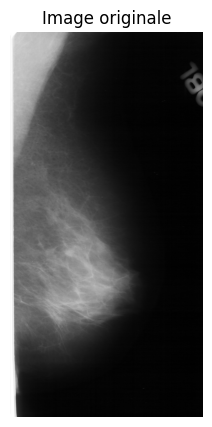

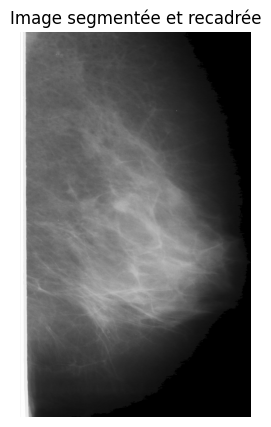

In [11]:
#Visualisation d'exemples de process_mammo sur des images miniDDSM "0-normales"
numéro_image= 10 # choisir une valeur entre 0 et 2332

path_obj = Path("../miniddsm2/MINI-DDSM-Complete-JPEG-82/0-normal/")
image_paths = list(path_obj.glob("*.jpg")) 
first_image = str(image_paths[numéro_image])

#chargement image originale
img=cv2.imread(first_image,0)
hauteur,largeur=img.shape
plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray') 
plt.title("Image originale")
plt.axis('off') 
plt.show()

#chargement image traitée
cropped_img,_=process_mammo(first_image)
plt.figure(figsize=(5,5))
plt.imshow(cropped_img, cmap='gray') 
plt.title("Image segmentée et recadrée")
plt.axis('off') 
plt.show()

In [12]:
#traitement des images et enregistrement dans un nouveau dataset
#paramètres:
nom_dataset_traite="nouveau_dataset_mini_ddsm_700_700" #à choisir
res_min= 700 #on évite les images de trop basse résolutions qui vont être surdimensionnée dans le Transform.Compose

#traitement des images
source_data_normal = "../miniddsm2/MINI-DDSM-Complete-JPEG-82/0-normal/"
source_data_cancer_benign="../miniddsm2/MINI-DDSM-Complete-JPEG-82/1-cancer_benign/"

path_obj_normal = Path(source_data_normal)
path_obj_cancer_benign= Path(source_data_cancer_benign)

image_normal_paths = list(path_obj_normal.glob("*.jpg")) 
image_cancer_paths = list(path_obj_cancer_benign.glob("*.jpg")) 

def traitement_image(chemin_dossier_destination):
    destination_cancer_benign= os.path.join(chemin_dossier_destination,"1-cancer_benign")
    destination_normal=os.path.join(chemin_dossier_destination,"0-normal")
    os.makedirs(chemin_dossier_destination, exist_ok=True)
    os.makedirs(destination_cancer_benign, exist_ok=True)
    os.makedirs(destination_normal, exist_ok=True)
    compteur_proportion_pas_ok=0
    i=0

    for image in tqdm(image_normal_paths):
        (new_image,b)=process_mammo(image)
        (hauteur,largeur)=new_image.shape
        if b==0 and hauteur>=res_min and largeur >=res_min:
            cv2.imwrite(os.path.join(destination_normal, f"image_{i}.jpg"), new_image)
        else:
            compteur_proportion_pas_ok=compteur_proportion_pas_ok+b
        i+=1
    for image in tqdm(image_cancer_paths):
        (new_image,b)=process_mammo(image)
        (hauteur,largeur)=new_image.shape
        if b==0 and hauteur>=res_min and largeur >=res_min:
            cv2.imwrite(os.path.join(destination_cancer_benign, f"image_{i}.jpg"), new_image)
        else:
            compteur_proportion_pas_ok=compteur_proportion_pas_ok+b
        i+=1
    return(f"traitement_et_enregistrement_terminé au chemin {chemin_dossier_destination} \n proportion d'images non aux proportions vindr : {compteur_proportion_pas_ok/i} \n ATTENTION : penser à enregistrer sur onyxia")

In [13]:
chemin_nouveau_data_set=os.path.join("../miniddsm2/",nom_dataset_traite)
traitement_image(chemin_dossier_destination=chemin_nouveau_data_set)

100%|██████████| 1333/1333 [00:28<00:00, 46.10it/s]


"traitement_et_enregistrement_terminé au chemin ../miniddsm2/nouveau_dataset_mini_ddsm_700_700 \n proportion d'images non aux proportions vindr : 0.15602836879432624 \n ATTENTION : penser à enregistrer sur onyxia"

In [18]:
#enregistrement sur le s3
!mc mirror ../miniddsm2/nouveau_dataset_mini_ddsm_700_700 s3/dimitri/stat_app/nouveau_dataset_mini_ddsm_700_700/

...e_3665.jpg: 869.66 MiB / 869.66 MiB ┃▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓┃ 89.76 MiB/s 9s